✅ Dataset loaded successfully!
Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



--- BASIC INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation  

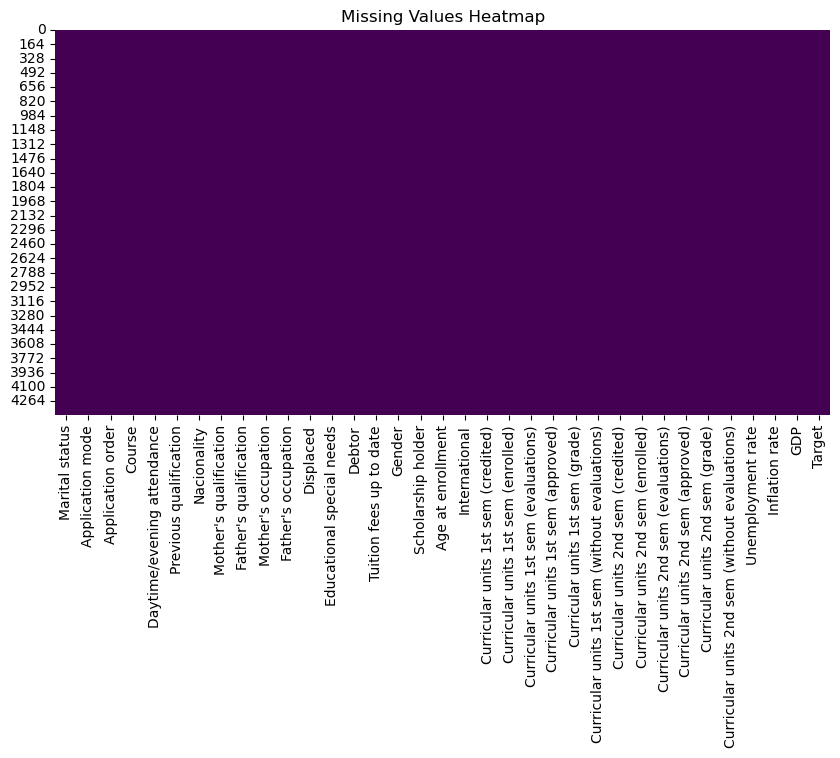


--- DUPLICATE ROWS ---
Total duplicates: 0
✅ No duplicate rows found.

--- TARGET DISTRIBUTION ---
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


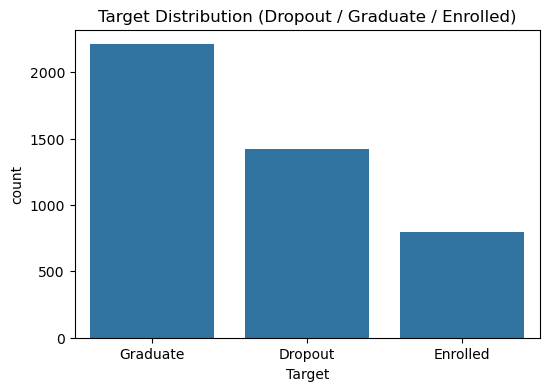


--- NUMERIC SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,6.886980,5.298964,1.00,1.00,8.000000,12.000000,18.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,9.899186,4.331792,1.00,6.00,10.000000,13.000000,17.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,2.531420,3.963707,1.00,1.00,1.000000,1.000000,17.000000
Nacionality,4424.0,1.254521,1.748447,1.00,1.00,1.000000,1.000000,21.000000
Mother's qualification,4424.0,12.322107,9.026251,1.00,2.00,13.000000,22.000000,29.000000
Father's qualification,4424.0,16.455244,11.044800,1.00,3.00,14.000000,27.000000,34.000000
Mother's occupation,4424.0,7.317812,3.997828,1.00,5.00,6.000000,10.000000,32.000000


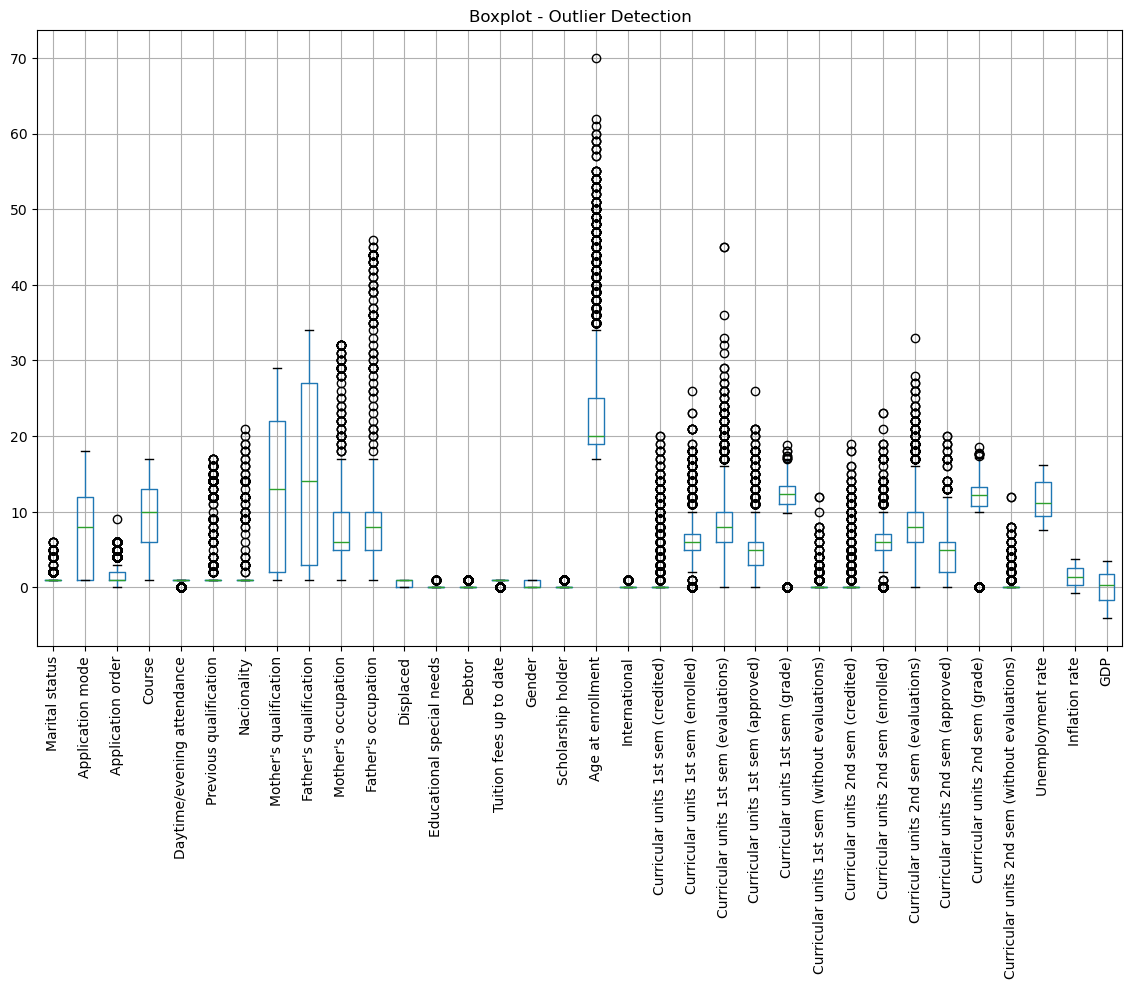


--- CATEGORICAL FEATURES & UNIQUE VALUES ---
Target: 3 unique values


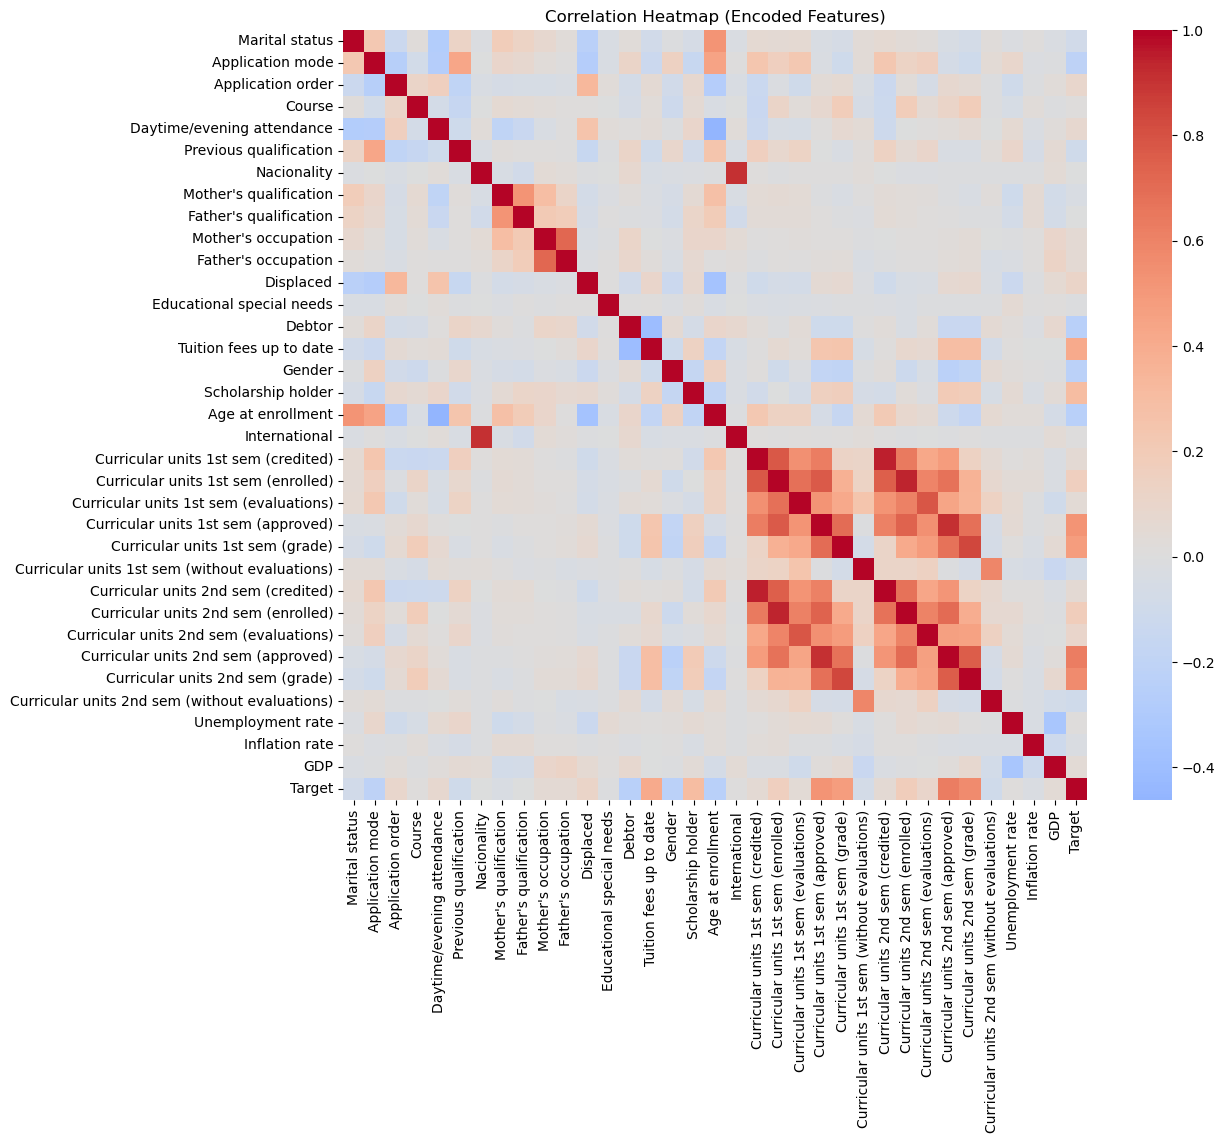


--- CLASS BALANCE ---
Target
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: proportion, dtype: float64
✅ Target classes are reasonably balanced.

=== DATA READINESS SUMMARY ===
Rows: 4424, Columns: 35
Missing values: 0
Duplicate rows: 0
Target column verified ✅
✅ Data quality check complete. Review outputs above for any warnings.


In [1]:
# Final Project
# ============================================================
# DATA QUALITY CHECK FOR: "Predicting Student Dropout Dataset"
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File path
data_path = r"C:\Users\fiker\Desktop\class\Machine learning\dataset.csv"

# Load the dataset
df = pd.read_csv(data_path)
print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

# ------------------------------------------
# 1. BASIC INFO
# ------------------------------------------
print("\n--- BASIC INFO ---")
df.info()

print("\n--- DATA TYPES SUMMARY ---")
print(df.dtypes.value_counts())

# ------------------------------------------
# 2. MISSING VALUES
# ------------------------------------------
print("\n--- MISSING VALUE CHECK ---")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) == 0:
    print("✅ No missing values found!")
else:
    print("⚠️ Missing values detected:")
    print(missing)

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# ------------------------------------------
# 3. DUPLICATE ROWS
# ------------------------------------------
duplicates = df.duplicated().sum()
print(f"\n--- DUPLICATE ROWS ---\nTotal duplicates: {duplicates}")
if duplicates > 0:
    print("⚠️ Consider removing duplicates with df.drop_duplicates().")
else:
    print("✅ No duplicate rows found.")

# ------------------------------------------
# 4. TARGET VARIABLE CHECK
# ------------------------------------------
target_col = "Target"
if target_col in df.columns:
    print("\n--- TARGET DISTRIBUTION ---")
    print(df[target_col].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(x=target_col, data=df, order=df[target_col].value_counts().index)
    plt.title("Target Distribution (Dropout / Graduate / Enrolled)")
    plt.show()
else:
    print(f"⚠️ Target column '{target_col}' not found!")

# ------------------------------------------
# 5. NUMERIC SUMMARY STATS
# ------------------------------------------
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("\n--- NUMERIC SUMMARY ---")
display(df[num_cols].describe().T)

# ------------------------------------------
# 6. OUTLIER DETECTION (Boxplot for key numeric features)
# ------------------------------------------
plt.figure(figsize=(14, 8))
df[num_cols].boxplot(rot=90)
plt.title("Boxplot - Outlier Detection")
plt.show()

# ------------------------------------------
# 7. CATEGORICAL VALUE CARDINALITY
# ------------------------------------------
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print("\n--- CATEGORICAL FEATURES & UNIQUE VALUES ---")
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

# ------------------------------------------
# 8. CORRELATION CHECK
# ------------------------------------------
# Encode categories temporarily for correlation heatmap
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Encoded Features)")
plt.show()

# ------------------------------------------
# 9. CLASS BALANCE CHECK
# ------------------------------------------
if target_col in df.columns:
    counts = df[target_col].value_counts(normalize=True)
    print("\n--- CLASS BALANCE ---")
    print(counts)
    if counts.min() < 0.15:
        print("⚠️ Warning: Target classes are imbalanced. Consider stratified sampling or class weighting.")
    else:
        print("✅ Target classes are reasonably balanced.")
else:
    print("⚠️ Skipping class balance check (target column missing).")

# ------------------------------------------
# 10. FINAL READINESS SUMMARY
# ------------------------------------------
print("\n=== DATA READINESS SUMMARY ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Missing values: {missing.sum() if len(missing)>0 else 0}")
print(f"Duplicate rows: {duplicates}")
if target_col in df.columns:
    print("Target column verified ✅")
else:
    print("⚠️ Target column missing!")
print("✅ Data quality check complete. Review outputs above for any warnings.")



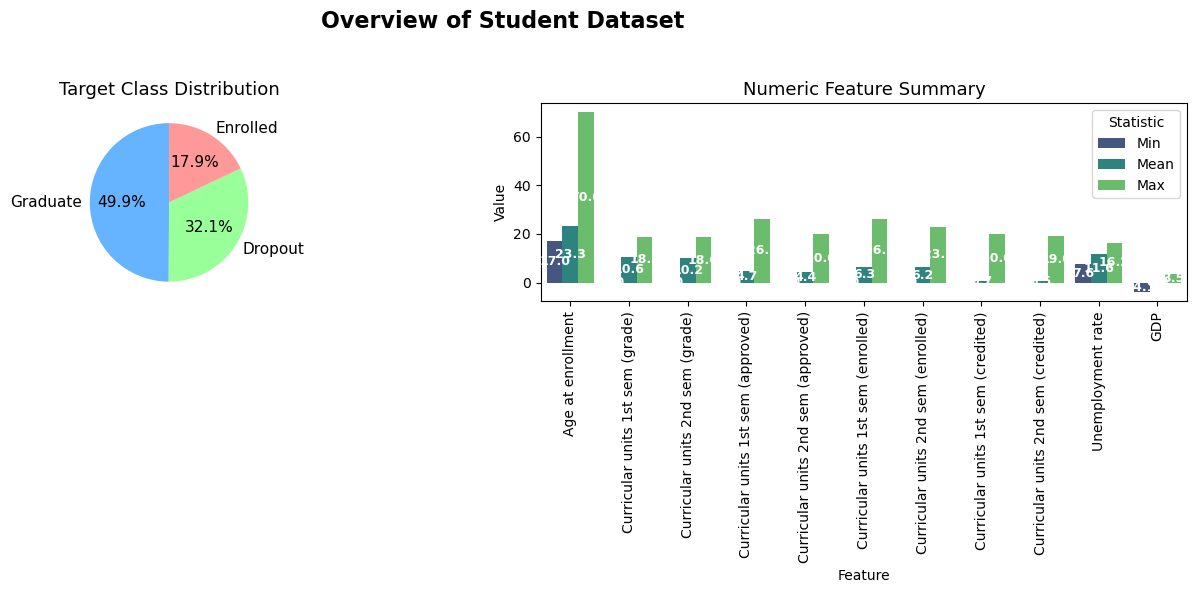

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data_path = r"C:\Users\fiker\Desktop\class\Machine learning\dataset.csv"
df = pd.read_csv(data_path)

# Create figure
plt.figure(figsize=(14,6))
plt.suptitle("Overview of Student Dataset", fontsize=16, fontweight='bold')

# -------------------------------
# Subplot 1: Target Distribution
# -------------------------------
plt.subplot(1,2,1)
target_counts = df['Target'].value_counts()
colors = ['#66b3ff','#99ff99','#ff9999']
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize':11})
plt.title("Target Class Distribution", fontsize=13)

# -------------------------------
# Subplot 2: Numeric Feature Stats
# -------------------------------

# List of numeric features (based on dataset)
numeric_features = [
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 1st sem (credited)',
    'Curricular units 2nd sem (credited)',
    'Unemployment rate',
    'GDP'
]

# Compute summary stats
summary_df = pd.DataFrame({
    'Feature': numeric_features,
    'Min': [df[col].min() for col in numeric_features],
    'Mean': [df[col].mean() for col in numeric_features],
    'Max': [df[col].max() for col in numeric_features]
})

# Melt for grouped barplot
summary_melt = summary_df.melt(id_vars='Feature', var_name='Statistic', value_name='Value')

plt.subplot(1,2,2)
ax = sns.barplot(data=summary_melt, x='Feature', y='Value', hue='Statistic', palette='viridis')
plt.title("Numeric Feature Summary", fontsize=13)
plt.ylabel("Value")
plt.xticks(rotation=90)
plt.legend(title='Statistic')

# Add labels inside bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='center', color='white',
                 fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


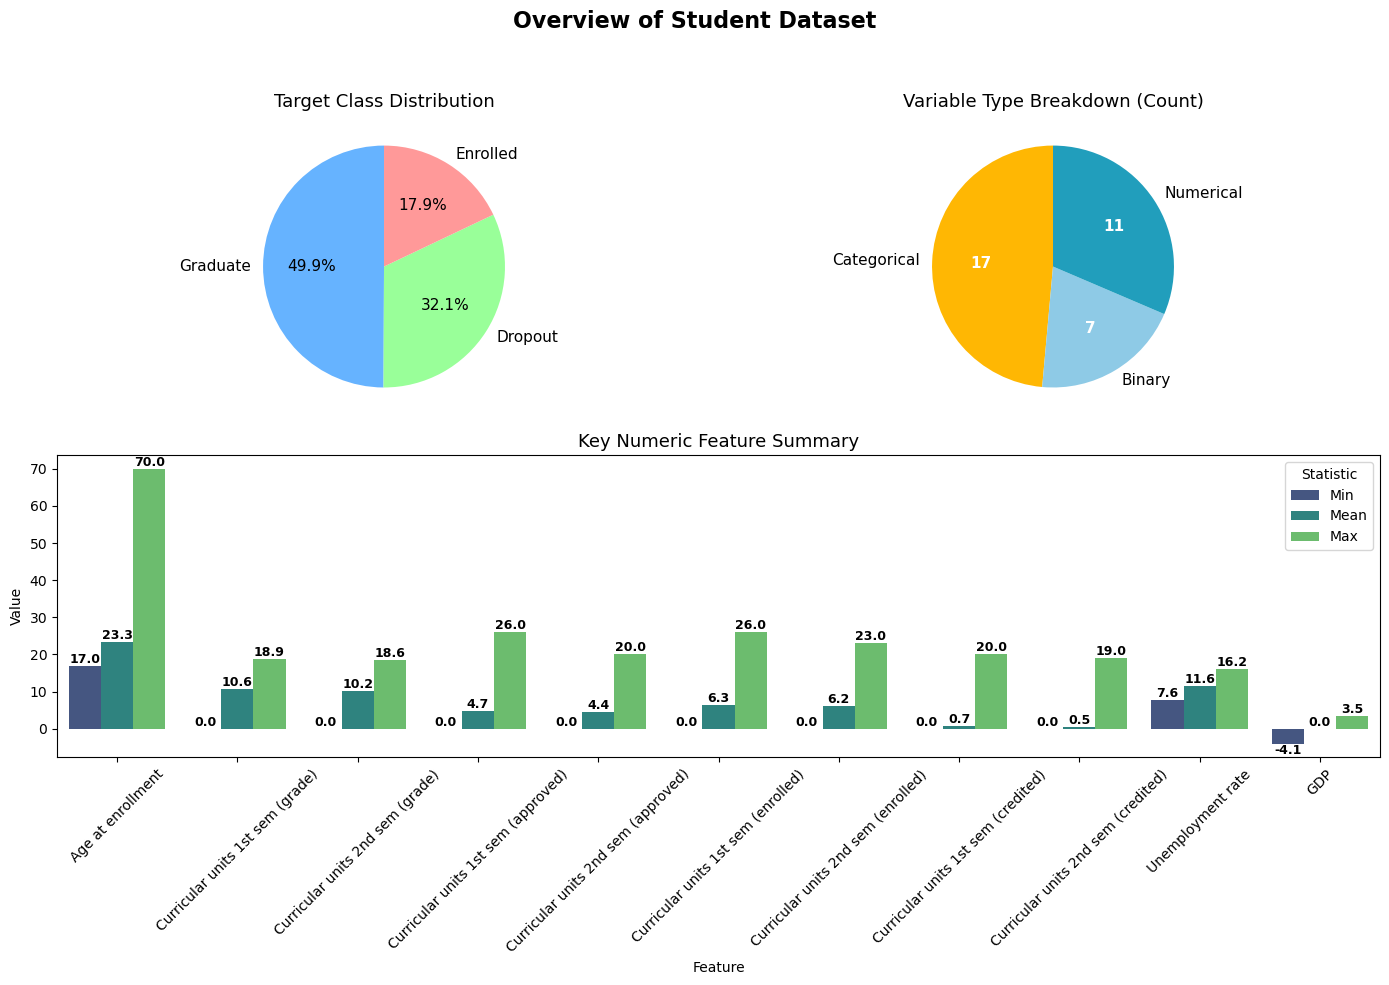

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data_path = r"C:\Users\fiker\Desktop\class\Machine learning\dataset.csv"
df = pd.read_csv(data_path)

# Create figure
plt.figure(figsize=(14,10))
plt.suptitle("Overview of Student Dataset", fontsize=16, fontweight='bold')

# -------------------------------
# Subplot 1: Target Distribution
# -------------------------------
plt.subplot(2,2,1)
target_counts = df['Target'].value_counts()
colors = ['#66b3ff','#99ff99','#ff9999']
plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize':11}
)
plt.title("Target Class Distribution", fontsize=13)

# -------------------------------
# Subplot 2: Variable Type Breakdown (with counts inside)
# -------------------------------
plt.subplot(2,2,2)
var_type_counts = {
    'Categorical': 17,
    'Binary': 7,
    'Numerical': 11
}
var_colors = ['#ffb703', '#8ecae6', '#219ebc']

# Use counts as labels inside the pie
wedges, texts, autotexts = plt.pie(
    var_type_counts.values(),
    labels=var_type_counts.keys(),
    colors=var_colors,
    startangle=90,
    textprops={'fontsize':11},
    autopct=lambda pct: f"{int(round(pct/100*sum(var_type_counts.values())))}"
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.title("Variable Type Breakdown (Count)", fontsize=13)

# -------------------------------
# Subplot 3: Numeric Feature Summary (Min, Mean, Max)
# -------------------------------
plt.subplot(2,1,2)
numeric_features = [
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 1st sem (credited)',
    'Curricular units 2nd sem (credited)',
    'Unemployment rate',
    'GDP'
]

summary_df = pd.DataFrame({
    'Feature': numeric_features,
    'Min': [df[col].min() for col in numeric_features],
    'Mean': [df[col].mean() for col in numeric_features],
    'Max': [df[col].max() for col in numeric_features]
})

summary_melt = summary_df.melt(id_vars='Feature', var_name='Statistic', value_name='Value')

ax = sns.barplot(data=summary_melt, x='Feature', y='Value', hue='Statistic', palette='viridis')
plt.title("Key Numeric Feature Summary", fontsize=13)
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend(title='Statistic')

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', color='black',
                 fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [11]:
# ============================
# STEP 2: TRAIN/TEST SPLIT + SCALING
# ============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data (80/20) stratified to keep class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("✅ Data split complete!")
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# Check class distribution in each set
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass distribution in testing set:")
print(y_test.value_counts(normalize=True).round(3))

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Scaling complete!")
print("Scaled feature sample (first 5 rows):")
print(X_train_scaled[:5])


✅ Data split complete!
Training set: (3539, 34)
Testing set: (885, 34)

Class distribution in training set:
Target_encoded
2    0.499
0    0.321
1    0.179
Name: proportion, dtype: float64

Class distribution in testing set:
Target_encoded
2    0.499
0    0.321
1    0.180
Name: proportion, dtype: float64

✅ Scaling complete!
Scaled feature sample (first 5 rows):
[[-0.29202044  1.3408157  -0.5562293   0.02058494  0.34785191  2.84260624
  -0.14213616 -1.1399305  -1.40240855 -1.33742623 -0.9795741  -1.10273753
  -0.10826349 -0.35141438  0.36646265  1.36078377 -0.58137442 -0.29582838
  -0.15781597  3.48126892  1.89837502  1.36342243  1.71190056  0.36485108
  -0.21095655  2.83604295  1.70012134  1.25065859  1.838465    0.30478051
  -0.19553048  0.87213808 -1.10347259  0.33959515]
 [-0.29202044  0.963663   -0.5562293  -0.44049157  0.34785191 -0.39091546
  -0.14213616 -1.25096798 -1.40240855  1.18154739 -1.18385888  0.90683411
  -0.10826349  2.8456434  -2.72879107  1.36078377 -0.58137442  2.3

In [13]:
# ============================
# STEP 3: TRAIN LOGISTIC REGRESSION MODEL
# ============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize model (balanced class weights to handle slight imbalance)
log_reg = LogisticRegression(
    multi_class='ovr',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train model
log_reg.fit(X_train_scaled, y_train)
print("✅ Logistic Regression model trained successfully!")

# Predict on test set
y_pred = log_reg.predict(X_test_scaled)

# Compute basic accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Data: {accuracy:.4f}")


C:\Users\fiker\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Logistic Regression model trained successfully!
Model Accuracy on Test Data: 0.7525


=== Classification Report ===
              precision    recall  f1-score   support

     Dropout       0.82      0.72      0.76       284
    Enrolled       0.46      0.57      0.51       159
    Graduate       0.85      0.84      0.84       442

    accuracy                           0.75       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.77      0.75      0.76       885


Macro F1-Score: 0.7062
Weighted F1-Score: 0.7581
Macro Precision: 0.7083
Macro Recall: 0.7100


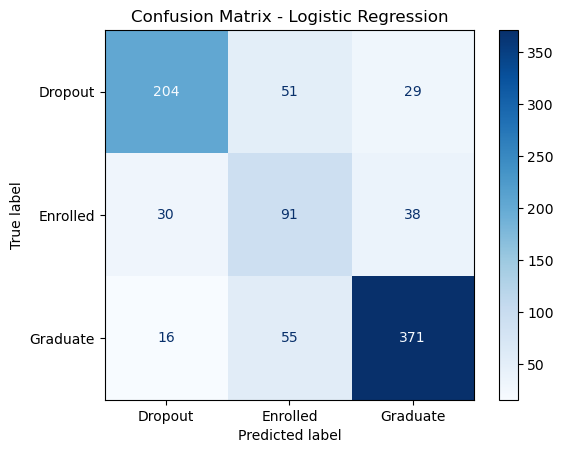

In [15]:
# ============================
# STEP 4: MODEL EVALUATION (DETAILED)
# ============================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

# Generate classification report
report = classification_report(y_test, y_pred, target_names=le.classes_)
print("=== Classification Report ===")
print(report)

# Compute average metrics
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
macro_precision = precision_score(y_test, y_pred, average='macro')
macro_recall = recall_score(y_test, y_pred, average='macro')

print(f"\nMacro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


=== Top 10 Positive Predictors of Dropout ===


,Feature,Coefficient,Odds_Ratio
0,Curricular units 2nd sem (enrolled),0.957125,2.604198
1,Curricular units 2nd sem (credited),0.533777,1.705360
2,Course,0.381251,1.464116
3,Age at enrollment,0.311869,1.365975
4,Curricular units 1st sem (grade),0.264083,1.302236
5,Curricular units 1st sem (credited),0.233651,1.263203
6,Unemployment rate,0.222701,1.249447
7,Debtor,0.219994,1.246069
8,Mother's qualification,0.211981,1.236125
9,Curricular units 1st sem (enrolled),0.197757,1.218667


=== Top 10 Negative Predictors of Dropout ===


,Feature,Coefficient,Odds_Ratio
24,Previous qualification,-0.093649,0.910603
25,Curricular units 1st sem (evaluations),-0.110990,0.894948
26,Father's occupation,-0.151458,0.859454
27,Scholarship holder,-0.179856,0.835390
28,Mother's occupation,-0.298214,0.742142
29,International,-0.305324,0.736884
30,Curricular units 2nd sem (grade),-0.311575,0.732293
31,Tuition fees up to date,-0.761473,0.466978
32,Curricular units 1st sem (approved),-0.843326,0.430277
33,Curricular units 2nd sem (approved),-2.056946,0.127844


C:\Users\fiker\AppData\Local\Temp\ipykernel_43836\790808685.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df.head(10), palette='Reds_r')


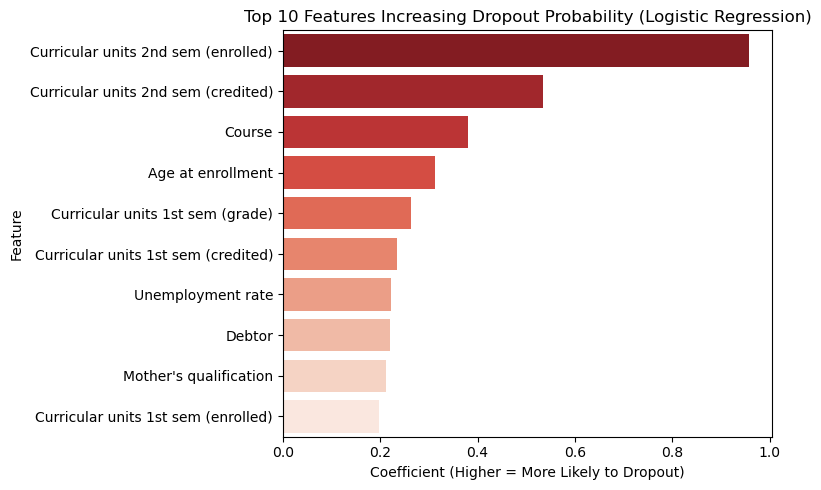

In [17]:
# ============================
# STEP 5: FEATURE IMPORTANCE (COEFFICIENTS)
# ============================

import numpy as np

# Get feature names
feature_names = X.columns

# Coefficients for each class
coefficients = log_reg.coef_
classes = le.classes_

# Convert coefficients to a DataFrame
coef_df = pd.DataFrame(coefficients.T, index=feature_names, columns=classes)

# Focus on the Dropout class
dropout_coef = coef_df['Dropout'].sort_values(ascending=False)

# Convert to odds ratios for easier interpretation
odds_ratios = np.exp(dropout_coef)

# Combine for display
importance_df = pd.DataFrame({
    'Feature': dropout_coef.index,
    'Coefficient': dropout_coef.values,
    'Odds_Ratio': odds_ratios.values
}).sort_values(by='Coefficient', ascending=False)

# Show top and bottom 10
print("=== Top 10 Positive Predictors of Dropout ===")
display(importance_df.head(10))

print("=== Top 10 Negative Predictors of Dropout ===")
display(importance_df.tail(10))

# Optional: visualize top 10
plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=importance_df.head(10), palette='Reds_r')
plt.title("Top 10 Features Increasing Dropout Probability (Logistic Regression)")
plt.xlabel("Coefficient (Higher = More Likely to Dropout)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


=== ROC-AUC Scores per Class ===
Dropout: 0.910
Enrolled: 0.776
Graduate: 0.921

Macro-average ROC-AUC: 0.869


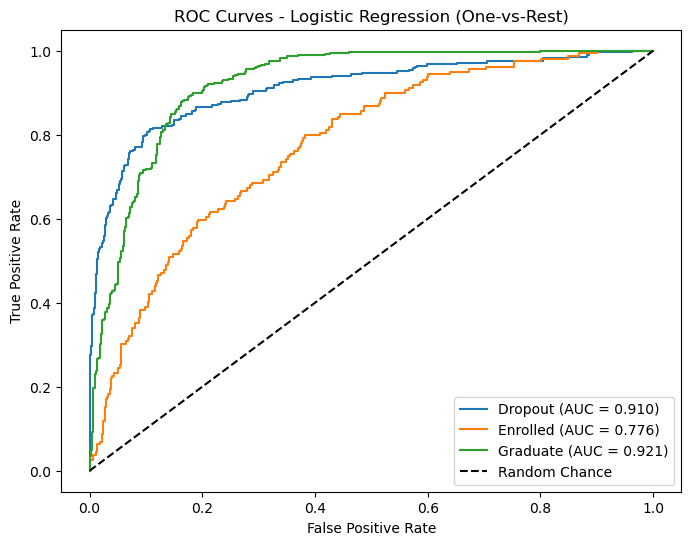

In [19]:
# ============================
# STEP 6: ROC CURVES & AUC SCORES
# ============================

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Get model probabilities
y_prob = log_reg.predict_proba(X_test_scaled)

# Compute ROC-AUC for each class
roc_auc = roc_auc_score(y_test_bin, y_prob, average=None)
mean_roc_auc = roc_auc_score(y_test_bin, y_prob, average="macro")

print("=== ROC-AUC Scores per Class ===")
for i, c in enumerate(le.classes_):
    print(f"{c}: {roc_auc[i]:.3f}")
print(f"\nMacro-average ROC-AUC: {mean_roc_auc:.3f}")

# Plot ROC curves
plt.figure(figsize=(8,6))
for i, c in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'{c} (AUC = {roc_auc[i]:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Logistic Regression (One-vs-Rest)')
plt.legend()
plt.show()


C:\Users\fiker\AppData\Local\Temp\ipykernel_43836\2555024340.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Odds_Ratio', y='Feature', data=importance_df.head(8), palette='Reds_r')


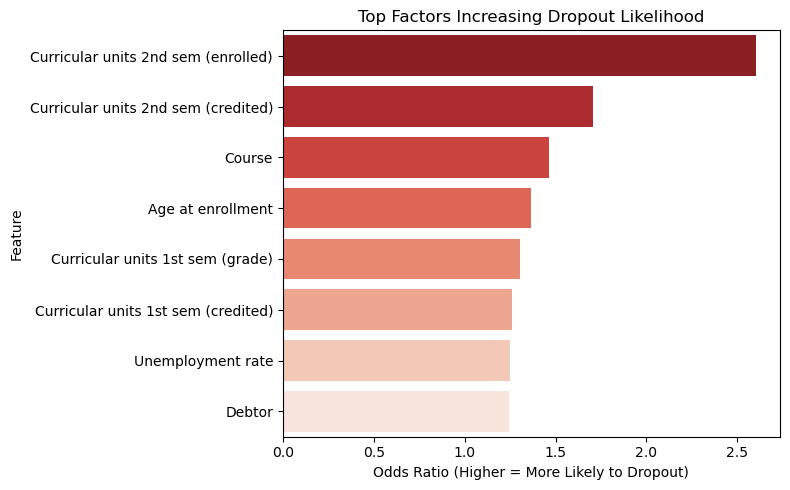

C:\Users\fiker\AppData\Local\Temp\ipykernel_43836\2555024340.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Odds_Ratio', y='Feature', data=importance_df.tail(8), palette='Blues')


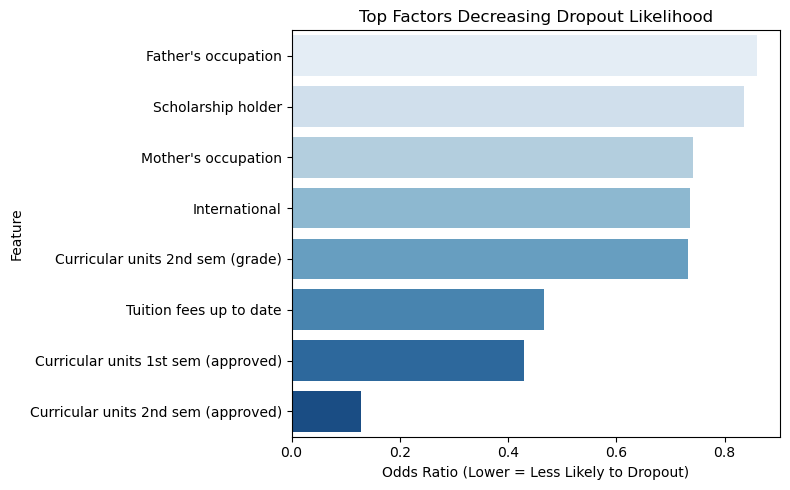

In [21]:
# ============================
# STEP 7: VISUAL SUMMARY (OPTIONAL)
# ============================

plt.figure(figsize=(8,5))
sns.barplot(x='Odds_Ratio', y='Feature', data=importance_df.head(8), palette='Reds_r')
plt.title("Top Factors Increasing Dropout Likelihood")
plt.xlabel("Odds Ratio (Higher = More Likely to Dropout)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='Odds_Ratio', y='Feature', data=importance_df.tail(8), palette='Blues')
plt.title("Top Factors Decreasing Dropout Likelihood")
plt.xlabel("Odds Ratio (Lower = Less Likely to Dropout)")
plt.tight_layout()
plt.show()


In [23]:
# ============================
# STEP 8: SAVE MODEL AND RESULTS
# ============================

import joblib
import json

# Save model and scaler
joblib.dump(log_reg, "logistic_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model and scaler saved successfully!")

# Save metrics summary
results_summary = {
    "accuracy": round(accuracy, 4),
    "macro_f1": round(macro_f1, 4),
    "weighted_f1": round(weighted_f1, 4),
    "macro_precision": round(macro_precision, 4),
    "macro_recall": round(macro_recall, 4),
    "roc_auc_macro": round(mean_roc_auc, 4)
}

with open("log_reg_results.json", "w") as f:
    json.dump(results_summary, f, indent=4)

print("\n✅ Evaluation results saved to log_reg_results.json")
print(results_summary)


✅ Model and scaler saved successfully!

✅ Evaluation results saved to log_reg_results.json
{'accuracy': 0.7525, 'macro_f1': 0.7062, 'weighted_f1': 0.7581, 'macro_precision': 0.7083, 'macro_recall': 0.71, 'roc_auc_macro': 0.8688}


In [27]:
import joblib, json

# Re-save model, scaler, and metrics directly to your folder
save_path = r"C:\Users\fiker\Desktop\class\Machine learning"

# Save model and scaler explicitly
joblib.dump(log_reg, save_path + "\\logistic_regression_model.pkl")
joblib.dump(scaler, save_path + "\\scaler.pkl")

# Re-save evaluation results
results_summary = {
    "accuracy": round(accuracy, 4),
    "macro_f1": round(macro_f1, 4),
    "weighted_f1": round(weighted_f1, 4),
    "macro_precision": round(macro_precision, 4),
    "macro_recall": round(macro_recall, 4),
    "roc_auc_macro": round(mean_roc_auc, 4)
}

with open(save_path + "\\log_reg_results.json", "w") as f:
    json.dump(results_summary, f, indent=4)

print("✅ Model, scaler, and metrics re-saved successfully to:")
print(save_path)


✅ Model, scaler, and metrics re-saved successfully to:
C:\Users\fiker\Desktop\class\Machine learning
